# 00 — Imports and Global Configurations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(palette='bright', style="white")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split, StratifiedKFold

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5
METRIC = root_mean_squared_error

# 01 - Imports

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/housing.csv")
TARGET = "median_house_value"


df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 02 - Feature Engineering
   - `population / households`
   - `total_rooms / households`
   - `total_bedrooms / households`
   - `total_bedrooms / total_rooms`

In [3]:
def add_features(df):
    df_new = df.copy()
    
    df_new['population_per_households'] = df_new['population'] / df_new['households']
    df_new['total_rooms_per_households'] = df_new['total_rooms'] / df_new['households']
    df_new['total_bedrooms_per_households'] = df_new['total_bedrooms'] / df_new['households']
    df_new['total_bedrooms_per_total_rooms'] = df_new['total_bedrooms'] / df_new['total_rooms']
    
    return df_new

df_fe = add_features(df)

print(f'shape dataframe antigo: {df.shape}')
print(f'shape dataframe novo: {df_fe.shape}')

df_fe[
    ['population_per_households', 
     'total_rooms_per_households', 
     'total_bedrooms_per_households', 
     'total_bedrooms_per_total_rooms']
].head()

shape dataframe antigo: (20640, 10)
shape dataframe novo: (20640, 14)


,population_per_households,total_rooms_per_households,total_bedrooms_per_households,total_bedrooms_per_total_rooms
0,2.555556,6.984127,1.023810,0.146591
1,2.109842,6.238137,0.971880,0.155797
2,2.802260,8.288136,1.073446,0.129516
3,2.547945,5.817352,1.073059,0.184458
4,2.181467,6.281853,1.081081,0.172096


## 03 — Target and features separation

In [4]:
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

display(X.head())
display(y.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,population_per_households,total_rooms_per_households,total_bedrooms_per_households,total_bedrooms_per_total_rooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,2.555556,6.984127,1.023810,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,2.109842,6.238137,0.971880,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,2.802260,8.288136,1.073446,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,2.547945,5.817352,1.073059,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,2.181467,6.281853,1.081081,0.172096


0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

# 04 - Split Train / Test

In [5]:
def income_stratify(X):
    income_strata = pd.cut(
        x=X['median_income'],
        bins=[0, 1.5, 3, 4.5, 6, np.inf],
        labels=['0', '1.5', '3', '4.5', '6+']
    )
    
    return income_strata

In [6]:
def split_data(X, y):
    
    income_strata = income_stratify(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=income_strata
    )
    
    return X_train, X_test, y_train, y_test

# 04 - Definition of numeric and categoric columns

In [7]:
df_fe.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'population_per_households',
       'total_rooms_per_households', 'total_bedrooms_per_households',
       'total_bedrooms_per_total_rooms'],
      dtype='object')

In [8]:
num_col = [
    'longitude',
    'latitude',
    'housing_median_age', 
    'total_rooms', 
    'total_bedrooms', 
    'population', 
    'households', 
    'median_income', 
    'population_per_households', 
    'total_rooms_per_households', 
    'total_bedrooms_per_households', 
    'total_bedrooms_per_total_rooms'
]

cat_col = ['ocean_proximity']

In [9]:
feature_cols = num_col + cat_col

missing = set(X.columns) - set(feature_cols)
print("Faltando:", missing)

duplicates = [c for c in feature_cols if feature_cols.count(c) > 1]
print("Duplicadas:", set(duplicates))

Faltando: set()
Duplicadas: set()


# 05 - Pipelines

## 05.1 - numeric pipeline

In [10]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [11]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('scaler', StandardScaler()),

])

## 05.2 - categoric pipeline

In [12]:
cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

## 05.3 - preprocessor

In [13]:
preprocess = ColumnTransformer(
    [
        ('num_prep', num_pipeline, num_col),
        ('cat_prep', cat_pipeline, cat_col)
    ],
    remainder='drop'
)

## 05.4 Final pipeline

In [14]:
def build_model_pipeline(regressor, preprocessor=None, target_transformer=None):
    
    # terá preprocessor
    if preprocessor:
        pipe = Pipeline([
            ('prep', preprocessor),
            ('reg', regressor)
        ])
    else:
        pipe = Pipeline([
            ('reg', regressor)
        ])
        
    # terá target transformer
    if target_transformer:
        model = TransformedTargetRegressor(pipe, transformer= target_transformer)
    else:
        model = pipe
    
    return model

In [15]:
pipe = build_model_pipeline(LinearRegression(), preprocess)

pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num_prep',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(degree=1,
                                                                                      include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'population_per_households',
                                                   'total_rooms_per_households',
                                                   'total_bedrooms_per_households',
                                                   'total_bedrooms_per_total_rooms']),
                                                 ('cat_prep',
                                                  Pipeline(steps=[('one_hot_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('reg', LinearRegression())])

In [16]:
pipe = build_model_pipeline(DummyRegressor(), preprocess)

pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num_prep',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(degree=1,
                                                                                      include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'population_per_households',
                                                   'total_rooms_per_households',
                                                   'total_bedrooms_per_households',
                                                   'total_bedrooms_per_total_rooms']),
                                                 ('cat_prep',
                                                  Pipeline(steps=[('one_hot_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('reg', DummyRegressor())])

In [17]:
def train_and_validate_regression_model(
    X,
    y,
    regressor,
    preprocessor=None,
    target_transformer=None,
    random_state=RANDOM_STATE
):
    model = build_model_pipeline(regressor, preprocessor, target_transformer)

    strata = income_stratify(X)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    # cross_validate aceita uma lista de (train_idx, test_idx)
    cv_splits = list(skf.split(X, strata))
    
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv_splits,
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    )
    return cv_results

In [20]:
def grid_search_cv_regressor(
    regressor,
    param_grid,
    preprocessor=None,
    target_transformer=None,
):
    model = build_model_pipeline(regressor, preprocessor, target_transformer)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    
    grid_search = GridSearchCV(
        estimator = model, 
        param_grid = param_grid, 
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
        refit='r2',
        verbose=1,
        cv = kf,
        return_train_score=True,
        n_jobs=-1
    )
    
    return grid_search

In [21]:
param_grid = {
    "reg__alpha": [1E-2, 0.1, 1.0],
    "reg__l1_ratio": [0.1, 0.5, 0.9],
    "prep__num_prep__poly__degree": [1, 2, 3]
}

gs_elastic = grid_search_cv_regressor(ElasticNet(), preprocessor=preprocess, param_grid=param_grid)

In [22]:
gs_elastic.fit(X, y)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/Users/tiagoprysthon/anaconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.510e+13, tolerance: 2.211e+10
  model = cd_fast.enet_coordinate_descent(
/Users/tiagoprysthon/anaconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.404e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(
/Users/tiagoprysthon/anaconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number o

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num_prep',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('poly',
                                                                                          PolynomialFeatures(degree=1,
                                                                                                             include_bias=False)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          't...
                                                                         Pipeline(steps=[('one_hot_encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('reg', ElasticNet())]),
             n_jobs=-1,
             param_grid={'prep__num_prep__poly__degree': [1, 2, 3],
                         'reg__alpha': [0.01, 0.1, 1.0],
                         'reg__l1_ratio': [0.1, 0.5, 0.9]},
             refit='r2', return_train_score=True,
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [27]:
gs_elastic.best_estimator_

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num_prep',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'population_per_households',
                                                   'total_rooms_per_households',
                                                   'total_bedrooms_per_households',
                                                   'total_bedrooms_per_total_rooms']),
                                                 ('cat_prep',
                                                  Pipeline(steps=[('one_hot_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('reg', ElasticNet(alpha=0.1))])

In [23]:
lista = {
    'linearRegression_preprocessor': {
        'regressor': LinearRegression(),
        'preprocessor': preprocess,
    },
    
    'elastic_preprocessor': {
        'regressor': ElasticNet(),
        'preprocessor': preprocess,
    },
    
    'dummyRegressor_preprocessor': {
        'regressor': DummyRegressor(),
        'preprocessor': preprocess,
    },
    
    'gridSearch_preprocessor': {
        'regressor': gs_elastic.best_estimator_['reg'],
        'preprocessor': gs_elastic.best_estimator_['prep'],
    },
}

pipes = {reg: train_and_validate_regression_model(X, y, **pipe) for reg, pipe in lista.items()}

/Users/tiagoprysthon/anaconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.737e+13, tolerance: 2.203e+10
  model = cd_fast.enet_coordinate_descent(
/Users/tiagoprysthon/anaconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.689e+13, tolerance: 2.199e+10
  model = cd_fast.enet_coordinate_descent(
/Users/tiagoprysthon/anaconda3/envs/machine_learning/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number o

In [24]:
def organize_results(results):

    for key, value in results.items():
        results[key]["time_seconds"] = (
            results[key]["fit_time"] + results[key]["score_time"]
        )

    df_results = (
        pd.DataFrame(results).T.reset_index().rename(columns={"index": "model"})
    )

    df_results_expanded = df_results.explode(
        df_results.columns[1:].to_list()
    ).reset_index(drop=True)

    try:
        df_results_expanded = df_results_expanded.apply(pd.to_numeric)
    except ValueError:
        pass

    return df_results_expanded

In [25]:
def plot_compare_models_metrics(df):
    fig, axs = plt.subplots(2, 2, figsize=(8,8), sharex=True)

    metrics = [
        'time_seconds',
        'test_r2',
        'test_neg_mean_absolute_error',
        'test_neg_root_mean_squared_error',
    ]

    rename_metrics = [
        'Tempo (s)',
        'R2',
        'MAE',
        'RMSE'
    ]

    for ax, metric, name in zip(axs.flatten(), metrics, rename_metrics):
        sns.boxplot(
            x='model',
            y=metric,
            data=df,
            ax=ax,
            showmeans=True    
        )
        ax.set_title(name)
        ax.tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

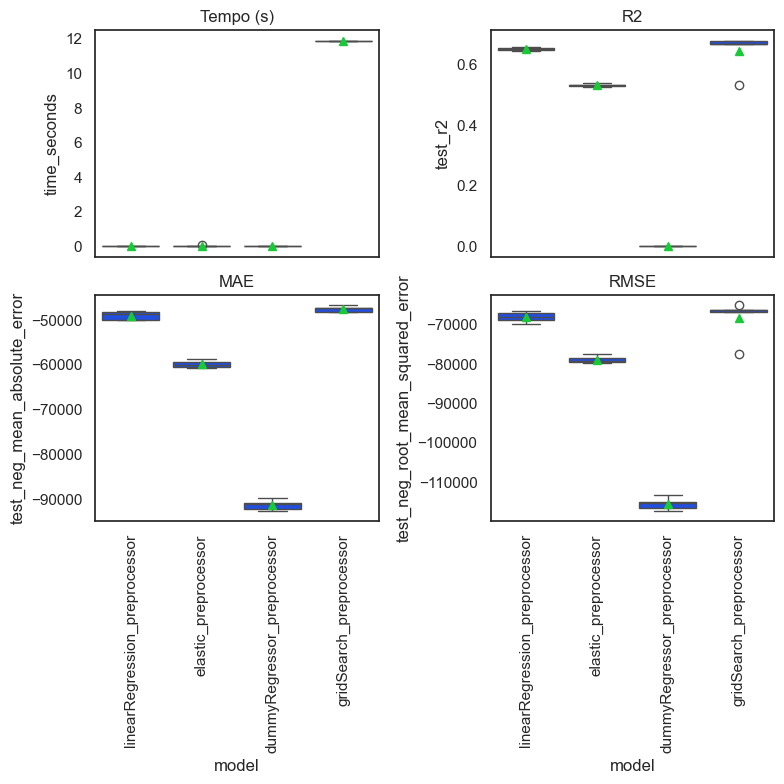

In [26]:
plot_compare_models_metrics(organize_results(pipes))